In [10]:
# Install all required packages
!pip install pandas numpy matplotlib scikit-learn statsmodels xgboost prophet tensorflow flask openpyxl joblib --quiet
print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [11]:
from google.colab import files
import os

# Upload sales_data.xlsx
print("/content/Forecasting Case- Study (2).xlsx")
uploaded = files.upload()

# Confirm upload
for filename in uploaded.keys():
    print(f"✅ Uploaded: {filename} ({len(uploaded[filename])} bytes)")

/content/Forecasting Case- Study (2).xlsx


Saving Forecasting Case- Study (2).xlsx to Forecasting Case- Study (2) (1).xlsx
✅ Uploaded: Forecasting Case- Study (2) (1).xlsx (251398 bytes)


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_excel('/content/Forecasting Case- Study (2).xlsx')

# Rename columns to match project
df.columns = ['State', 'Date', 'Sales', 'Category']

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort
df = df.sort_values(['State', 'Date']).reset_index(drop=True)

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (8084, 4)

First 5 Rows:


,State,Date,Sales,Category
0,Alabama,2019-01-12,109574036.0,Beverages
1,Alabama,2019-03-11,112189103.8,Beverages
2,Alabama,2019-06-10,129106730.4,Beverages
3,Alabama,2019-08-12,108083723.8,Beverages
4,Alabama,2019-10-11,110932912.8,Beverages


In [13]:
# Basic info
print("Date Range:", df['Date'].min(), "to", df['Date'].max())
print("Total States:", df['State'].nunique())
print("States:", sorted(df['State'].unique()))
print("\nCategories:", df['Category'].unique())
print("\nMissing Values:\n", df.isnull().sum())
print("\nSales Summary:")
df['Sales'].describe()

Date Range: 2019-01-12 00:00:00 to 2023-12-03 00:00:00
Total States: 43
States: ['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Florida', 'Georgia', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Nebraska', 'Nevada', 'New Hampshire', 'New Mexico', 'New York', 'North Carolina', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

Categories: ['Beverages']

Missing Values:
 State       0
Date        0
Sales       0
Category    0
dtype: int64

Sales Summary:


,Sales
count,8.084000e+03
mean,1.658580e+08
std,1.610566e+08
min,9.732839e+06
25%,6.393281e+07
50%,1.171426e+08
75%,2.010132e+08
max,9.853746e+08


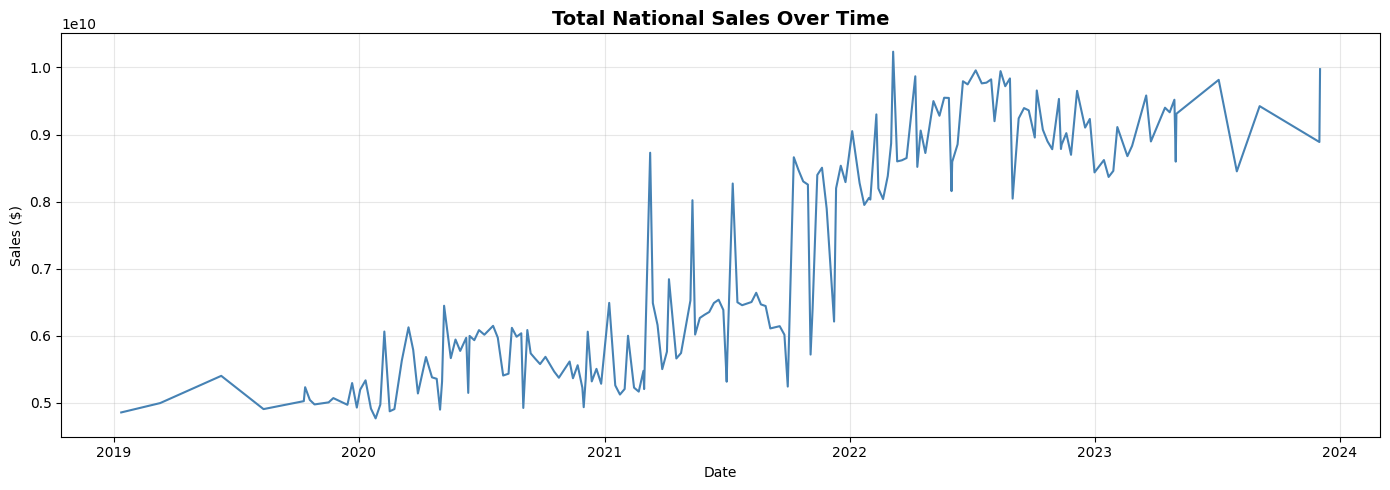

In [14]:
# Plot national total sales over time
national = df.groupby('Date')['Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(national['Date'], national['Sales'], color='steelblue', linewidth=1.5)
plt.title('Total National Sales Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

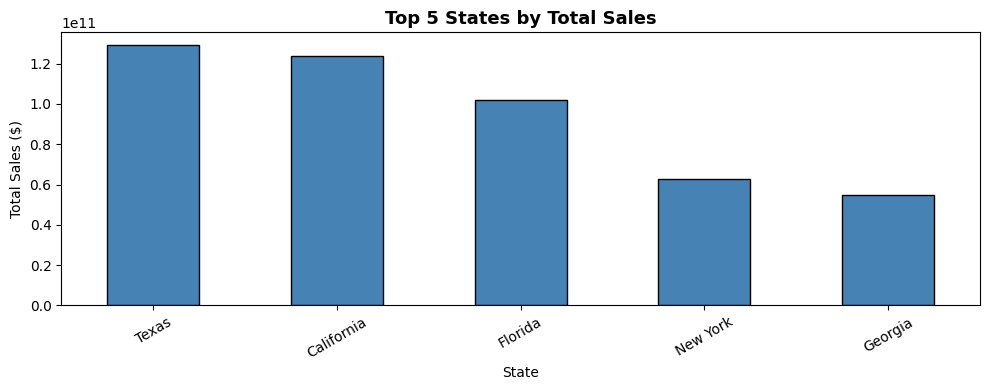

State
Texas         1.290921e+11
California    1.240391e+11
Florida       1.020484e+11
New York      6.282658e+10
Georgia       5.504005e+10
Name: Sales, dtype: float64


In [15]:
# Top 5 states by total sales
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 4))
top_states.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 5 States by Total Sales', fontsize=13, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print(top_states)

In [16]:
def create_features(state_df):
    """
    Create lag + rolling features for a single state DataFrame.
    Input df must have 'Sales' column and be indexed by Date.
    """
    data = state_df[['Sales']].copy()

    # Lag features (matches train_all_states.py)
    data['lag_1']  = data['Sales'].shift(1)
    data['lag_7']  = data['Sales'].shift(7)
    data['lag_30'] = data['Sales'].shift(30)

    # Rolling statistics
    data['rolling_mean'] = data['Sales'].rolling(4).mean()
    data['rolling_std']  = data['Sales'].rolling(4).std()

    # Drop NaN rows from lagging
    data = data.dropna()
    return data

# Demo: features for California
ca_df = df[df['State'] == 'California'].set_index('Date')
ca_features = create_features(ca_df)

print(f"California feature data shape: {ca_features.shape}")
ca_features.head()

California feature data shape: (158, 6)


,Sales,lag_1,lag_7,lag_30,rolling_mean,rolling_std
Date,,,,,,
2020-05-07,585581852.4,489779220.2,514100498.9,444766890.6,5.093616e+08,5.688827e+07
2020-05-17,506672447.8,585581852.4,465090389.2,492597099.4,5.080394e+08,5.686916e+07
2020-05-24,528426454.4,506672447.8,554931496.9,506587724.1,5.276150e+08,4.175704e+07
2020-05-31,525499508.9,528426454.4,499937571.8,449865324.4,5.365451e+08,3.408272e+07
2020-06-09,590828387.0,525499508.9,511961312.5,497063951.7,5.378567e+08,3.660641e+07


In [17]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Prepare features
FEATURE_COLS = ['lag_1', 'lag_7', 'lag_30', 'rolling_mean', 'rolling_std']

X = ca_features[FEATURE_COLS]
y = ca_features['Sales']

# Train/test split — last 8 records as test (matches project)
split = len(X) - 8
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

# Train XGBoost
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict
xgb_preds = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))

print(f"\nXGBoost RMSE (California): {xgb_rmse:,.0f}")

Train size: 150 | Test size: 8

XGBoost RMSE (California): 46,457,123


In [18]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Raw sales values for California
sales_data = ca_df[['Sales']].values

# Scale
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(sales_data)

# Create sequences (sequence_length=10 as in main.py)
sequence_length = 10
X_lstm, y_lstm = [], []

for i in range(sequence_length, len(scaled_data)):
    X_lstm.append(scaled_data[i - sequence_length:i])
    y_lstm.append(scaled_data[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

# Train/test split — last 8
split_lstm = len(X_lstm) - 8
X_train_lstm = X_lstm[:split_lstm]
X_test_lstm  = X_lstm[split_lstm:]
y_train_lstm = y_lstm[:split_lstm]
y_test_lstm  = y_lstm[split_lstm:]

# Build LSTM model (matches main.py)
lstm_model = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train_lstm.shape[1], 1)),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Train LSTM
history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=20,
    batch_size=8,
    verbose=1
)

# Predict
lstm_preds_scaled = lstm_model.predict(X_test_lstm)
lstm_preds = scaler.inverse_transform(lstm_preds_scaled)
lstm_actual = scaler.inverse_transform(y_test_lstm)

lstm_rmse = np.sqrt(mean_squared_error(lstm_actual, lstm_preds))
print(f"\nLSTM RMSE (California): {lstm_rmse:,.0f}")

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.1550
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0306
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0214
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0198
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0194
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0190
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0190
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0192
Epoch 9/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0183
Epoch 10/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0184
Epoch 11/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0182
Epoch 12/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0181
Epoch 13/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0180
Epoch 14/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0180
Epoch 15/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0184
Epoch 16/20
22/22 

In [20]:
from statsmodels.tsa.arima.model import ARIMA

# Use the California sales series
ca_sales = ca_df['Sales'].values

# Train/test split
split_arima = len(ca_sales) - 8
train_arima = ca_sales[:split_arima]
test_arima  = ca_sales[split_arima:]

# Fit ARIMA(2,1,2)
arima_model = ARIMA(train_arima, order=(2, 1, 2))
arima_fit = arima_model.fit()

# Forecast next 8 steps
arima_preds = arima_fit.forecast(steps=8)

arima_rmse = np.sqrt(mean_squared_error(test_arima, arima_preds))
print(f"ARIMA RMSE (California): {arima_rmse:,.0f}")

ARIMA RMSE (California): 62,760,979


In [21]:
from prophet import Prophet

# Prophet requires columns: ds (date), y (value)
prophet_df = ca_df.reset_index()[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})

# Train/test split
prophet_train = prophet_df.iloc[:-8]
prophet_test  = prophet_df.iloc[-8:]

# Fit Prophet
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_model.fit(prophet_train)

# Forecast
future = prophet_model.make_future_dataframe(periods=8, freq='W')
prophet_forecast = prophet_model.predict(future)
prophet_preds = prophet_forecast['yhat'].iloc[-8:].values

prophet_rmse = np.sqrt(mean_squared_error(prophet_test['y'].values, prophet_preds))
print(f"Prophet RMSE (California): {prophet_rmse:,.0f}")

Prophet RMSE (California): 68,303,104



=== Model Comparison (California) ===
Model                      RMSE
--------------------------------
XGBoost              46,457,123
LSTM                 52,850,392
ARIMA                62,760,979
Prophet              68,303,104

✅ Best Model: XGBoost


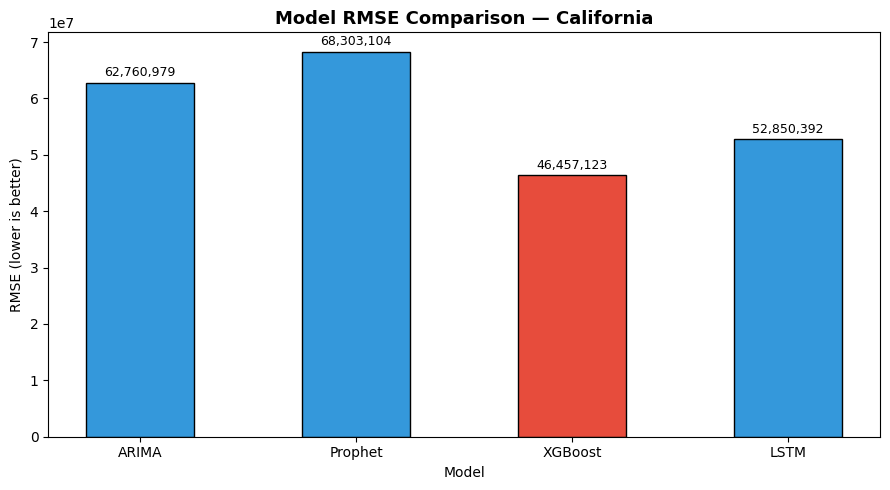


🏆 Best Model = XGBoost (RMSE: 46,457,123)


In [22]:
# Collect all RMSE scores (California)
scores = {
    'ARIMA':   arima_rmse,
    'Prophet': prophet_rmse,
    'XGBoost': xgb_rmse,
    'LSTM':    lstm_rmse
}

# Print comparison table
print("\n=== Model Comparison (California) ===")
print(f"{'Model':<12} {'RMSE':>18}")
print("-" * 32)
for model, score in sorted(scores.items(), key=lambda x: x[1]):
    print(f"{model:<12} {score:>18,.0f}")

best_model = min(scores, key=scores.get)
print(f"\n✅ Best Model: {best_model}")
# RMSE bar chart
colors = ['#e74c3c' if m == best_model else '#3498db' for m in scores]

plt.figure(figsize=(9, 5))
bars = plt.bar(scores.keys(), scores.values(), color=colors, edgecolor='black', width=0.5)
plt.title('Model RMSE Comparison — California', fontsize=13, fontweight='bold')
plt.ylabel('RMSE (lower is better)')
plt.xlabel('Model')

for bar, val in zip(bars, scores.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print(f"\n🏆 Best Model = {best_model} (RMSE: {scores[best_model]:,.0f})")

In [23]:
import joblib
import os

# Create models directory
os.makedirs('models', exist_ok=True)

FEATURE_COLS = ['lag_1', 'lag_7', 'lag_30', 'rolling_mean', 'rolling_std']
all_states = df['State'].unique()
trained_states = []
skipped_states  = []

print(f"Training XGBoost for {len(all_states)} states...\n")

for state in sorted(all_states):
    state_df = df[df['State'] == state].set_index('Date')
    data = create_features(state_df)

    if len(data) < 20:
        print(f"  ⚠️  Skipping {state} — insufficient data ({len(data)} rows)")
        skipped_states.append(state)
        continue

    X = data[FEATURE_COLS]
    y = data['Sales']

    model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
    model.fit(X, y)

    model_path = f'models/{state}_xgboost.pkl'
    joblib.dump(model, model_path)
    trained_states.append(state)
    print(f"  ✅ {state} → {model_path}")

print(f"\n🎉 Done! Trained: {len(trained_states)} states | Skipped: {len(skipped_states)}")

Training XGBoost for 43 states...

  ✅ Alabama → models/Alabama_xgboost.pkl
  ✅ Arizona → models/Arizona_xgboost.pkl
  ✅ Arkansas → models/Arkansas_xgboost.pkl
  ✅ California → models/California_xgboost.pkl
  ✅ Colorado → models/Colorado_xgboost.pkl
  ✅ Connecticut → models/Connecticut_xgboost.pkl
  ✅ Florida → models/Florida_xgboost.pkl
  ✅ Georgia → models/Georgia_xgboost.pkl
  ✅ Illinois → models/Illinois_xgboost.pkl
  ✅ Indiana → models/Indiana_xgboost.pkl
  ✅ Iowa → models/Iowa_xgboost.pkl
  ✅ Kansas → models/Kansas_xgboost.pkl
  ✅ Kentucky → models/Kentucky_xgboost.pkl
  ✅ Louisiana → models/Louisiana_xgboost.pkl
  ✅ Maine → models/Maine_xgboost.pkl
  ✅ Maryland → models/Maryland_xgboost.pkl
  ✅ Massachusetts → models/Massachusetts_xgboost.pkl
  ✅ Michigan → models/Michigan_xgboost.pkl
  ✅ Minnesota → models/Minnesota_xgboost.pkl
  ✅ Mississippi → models/Mississippi_xgboost.pkl
  ✅ Missouri → models/Missouri_xgboost.pkl
  ✅ Nebraska → models/Nebraska_xgboost.pkl
  ✅ Nevada → mode

In [24]:
def simulate_forecast_api(state, n_weeks=8):
    """
    Simulates the Flask /forecast/<state> endpoint.
    Loads the saved XGBoost model and generates n_weeks ahead forecast.
    """
    model_path = f'models/{state}_xgboost.pkl'

    if not os.path.exists(model_path):
        return {"error": f"Model not found for state: {state}"}

    model = joblib.load(model_path)

    # Seed values from actual last known data for the state
    state_df = df[df['State'] == state].set_index('Date')
    data = create_features(state_df)
    last_row = data.iloc[-1]

    lag_1        = last_row['Sales']
    lag_7        = last_row['lag_7']
    lag_30       = last_row['lag_30']
    rolling_mean = last_row['rolling_mean']
    rolling_std  = last_row['rolling_std']

    forecasts = []
    for i in range(n_weeks):
        sample = pd.DataFrame([{
            'lag_1': lag_1,
            'lag_7': lag_7,
            'lag_30': lag_30,
            'rolling_mean': rolling_mean,
            'rolling_std': rolling_std
        }])
        prediction = model.predict(sample)[0]
        forecasts.append(float(prediction))

        # Rolling update (matches app.py logic)
        lag_30 = lag_7
        lag_7  = lag_1
        lag_1  = prediction
        rolling_mean = (rolling_mean + prediction) / 2

    return {
        "state": state,
        "best_model": "XGBoost",
        "forecast_next_8_weeks": forecasts
    }

# Test: California
result = simulate_forecast_api('California')
print("\n📡 API Response:")
import json
print(json.dumps(result, indent=2))


📡 API Response:
{
  "state": "California",
  "best_model": "XGBoost",
  "forecast_next_8_weeks": [
    876062208.0,
    882086464.0,
    895954176.0,
    889319168.0,
    882967936.0,
    887821184.0,
    895954176.0,
    884943808.0
  ]
}


In [25]:
# Test: Texas
result_tx = simulate_forecast_api('Texas')
print("\n📡 API Response (Texas):")
print(json.dumps(result_tx, indent=2))


📡 API Response (Texas):
{
  "state": "Texas",
  "best_model": "XGBoost",
  "forecast_next_8_weeks": [
    874103808.0,
    857821376.0,
    854929472.0,
    843259648.0,
    856019840.0,
    834779968.0,
    824450816.0,
    828333376.0
  ]
}


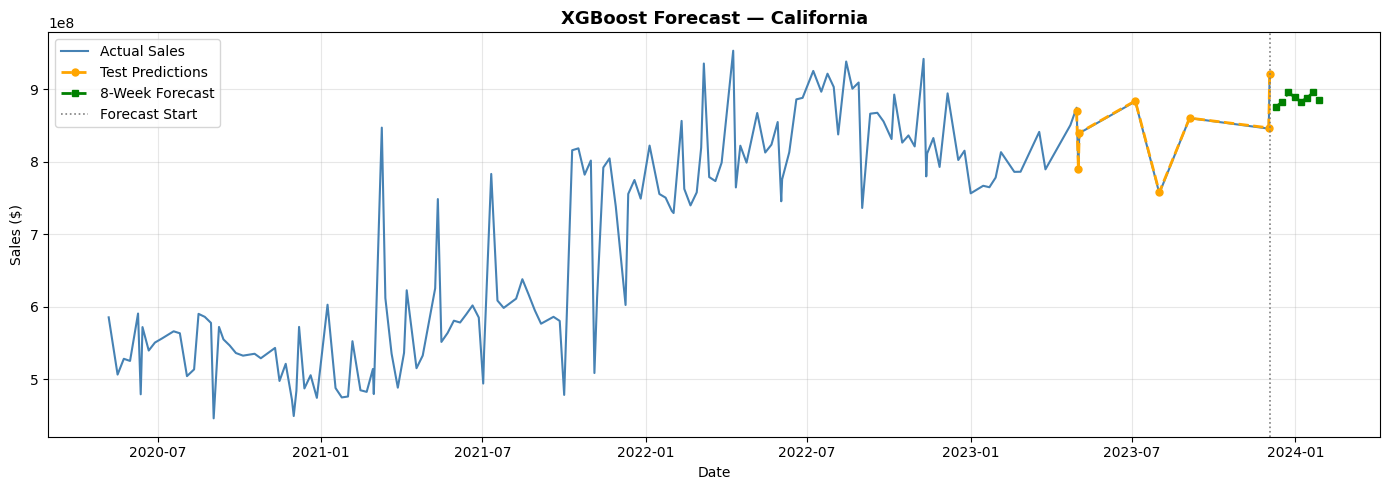

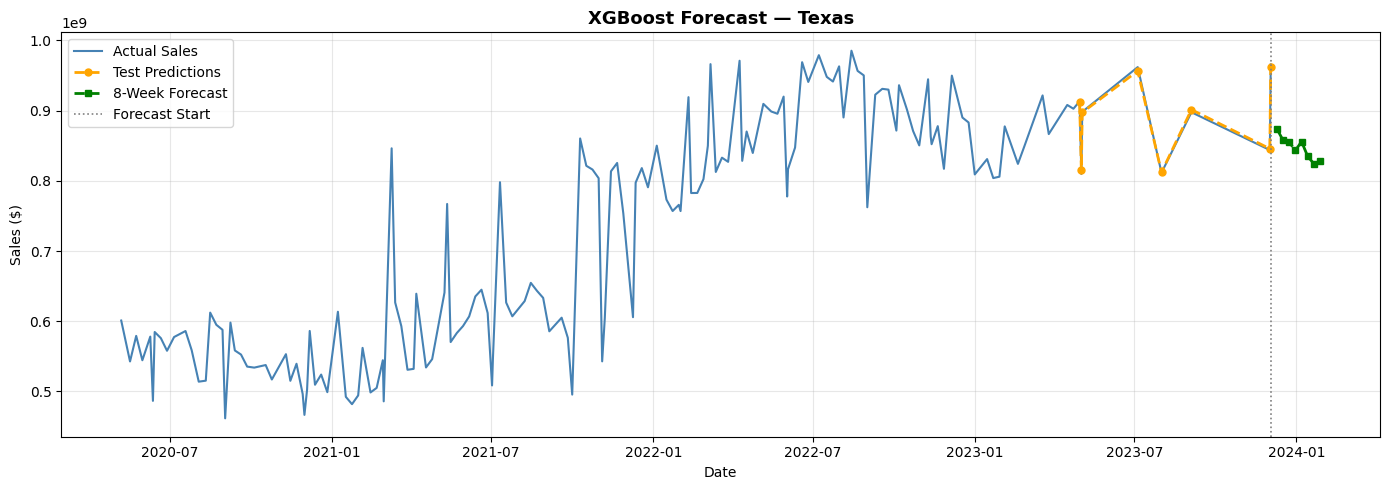

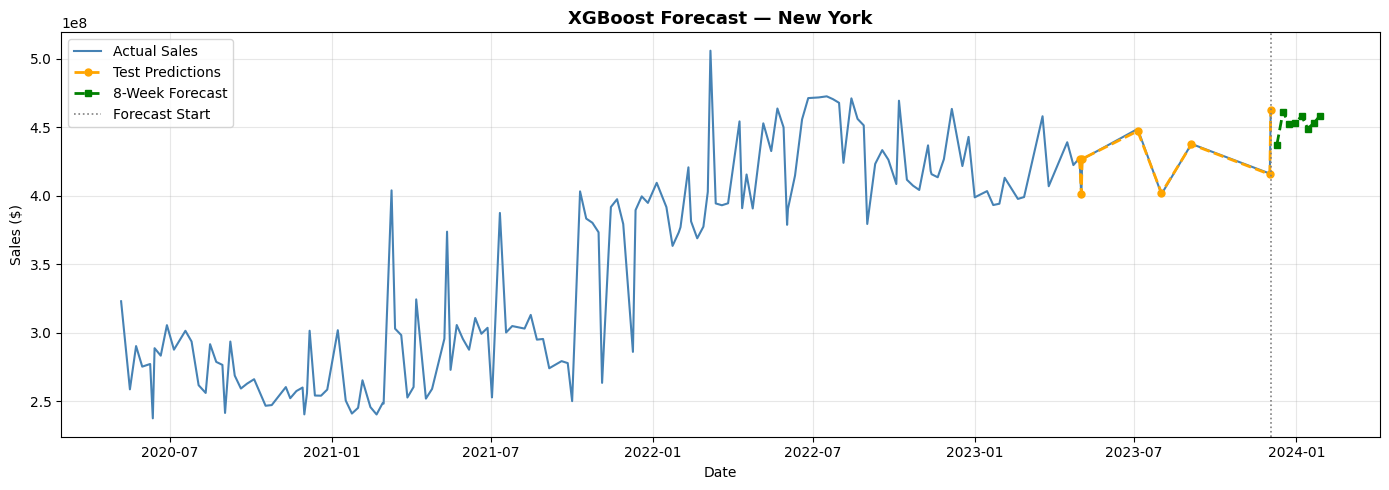

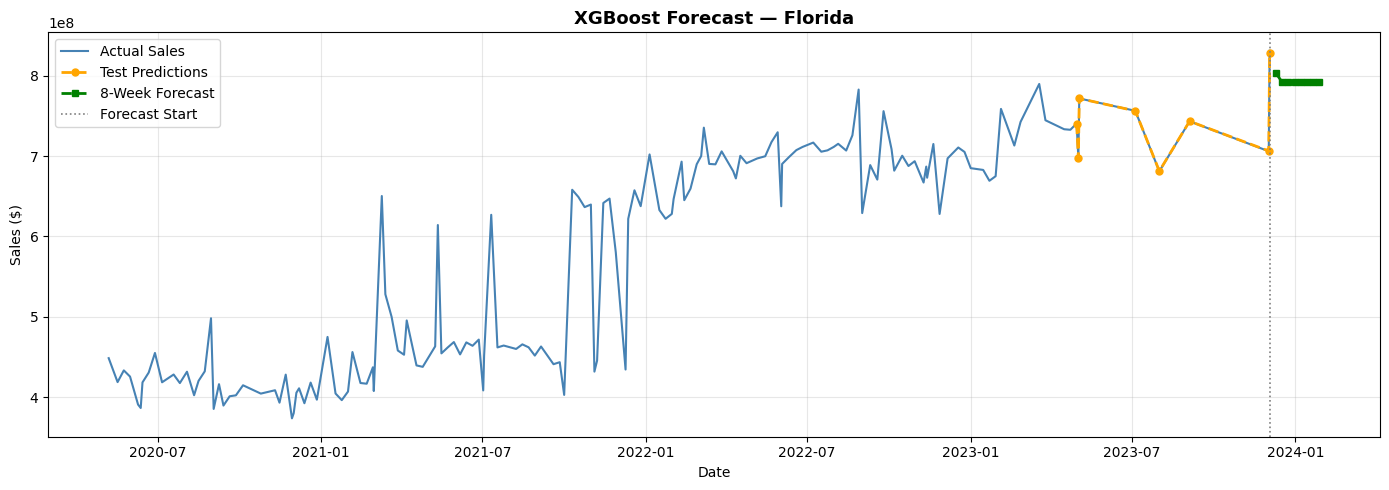

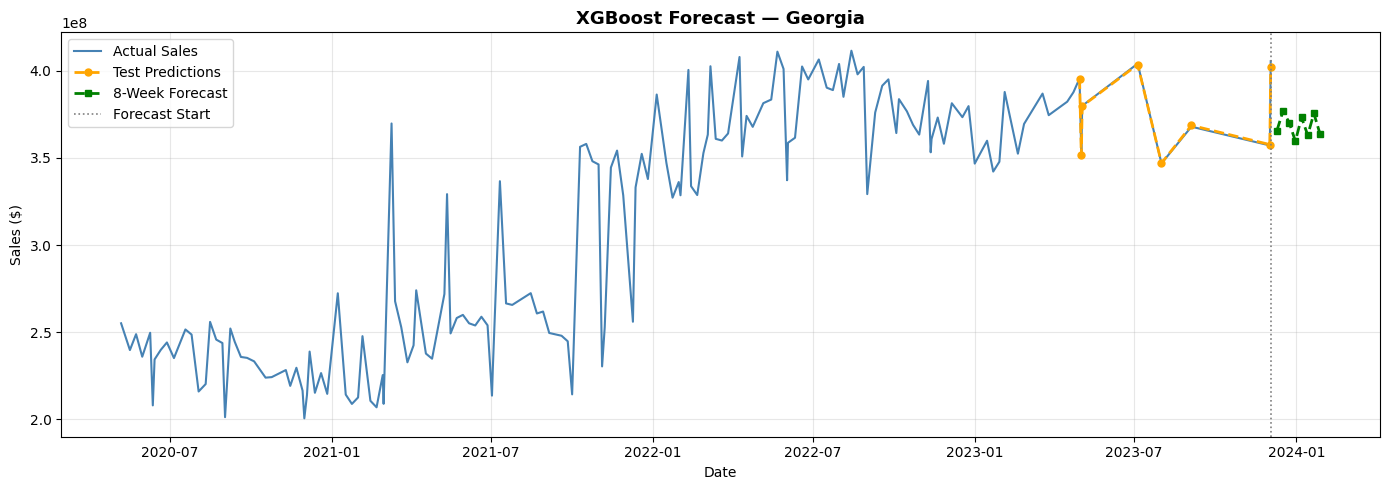

In [26]:
def plot_forecast(state):
    state_df = df[df['State'] == state].set_index('Date')
    data = create_features(state_df)

    X = data[FEATURE_COLS]
    y = data['Sales']
    split = len(X) - 8

    model = joblib.load(f'models/{state}_xgboost.pkl')
    preds_test = model.predict(X.iloc[split:])

    # Future forecast
    api_result = simulate_forecast_api(state)
    future_vals = api_result['forecast_next_8_weeks']

    last_date = data.index[-1]
    future_dates = pd.date_range(start=last_date, periods=9, freq='W')[1:]
    test_dates   = data.index[split:]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(data.index, y.values, label='Actual Sales', color='steelblue', linewidth=1.5)
    ax.plot(test_dates, preds_test, label='Test Predictions', color='orange',
            linewidth=2, linestyle='--', marker='o', markersize=5)
    ax.plot(future_dates, future_vals, label='8-Week Forecast', color='green',
            linewidth=2, linestyle='--', marker='s', markersize=5)
    ax.axvline(x=last_date, color='gray', linestyle=':', linewidth=1.2, label='Forecast Start')
    ax.set_title(f'XGBoost Forecast — {state}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Sales ($)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot for top states
for state in ['California', 'Texas', 'New York', 'Florida', 'Georgia']:
    if state in trained_states:
        plot_forecast(state)

In [27]:
import zipfile

zip_path = 'xgboost_state_models.zip'

with zipfile.ZipFile(zip_path, 'w') as zf:
    for fname in os.listdir('models'):
        if fname.endswith('.pkl'):
            zf.write(os.path.join('models', fname), fname)

print(f"✅ Models zipped: {zip_path}")

# Download
files.download(zip_path)
print("📦 Downloading...")


✅ Models zipped: xgboost_state_models.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 Downloading...


In [28]:
# ==============================
# INSTALL LIBRARIES
# ==============================
!pip install gradio pandas numpy scikit-learn statsmodels prophet xgboost openpyxl

# ==============================
# IMPORT LIBRARIES
# ==============================
import gradio as gr
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

# ==============================
# LOAD EXCEL DATA
# ==============================
df = pd.read_excel("/content/Forecasting Case- Study (2).xlsx")

# ==============================
# FIX COLUMN NAMES
# ==============================
df.columns = df.columns.str.strip().str.lower()

# Rename total -> sales
df = df.rename(columns={
    'total': 'sales'
})

print("✅ Columns in dataset:", df.columns)

# ==============================
# CHECK REQUIRED COLUMNS
# ==============================
required_cols = ['date', 'sales', 'state']

for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"❌ Missing column: {col}")

# ==============================
# DATE CONVERSION
# ==============================
df['date'] = pd.to_datetime(df['date'])

# Sort data
df = df.sort_values('date')

# ==============================
# XGBOOST FORECAST FUNCTION
# ==============================
def train_and_select(data):

    # Sort by date
    data = data.sort_values("date")

    # Create lag features
    temp = data.copy()

    temp['lag1'] = temp['sales'].shift(1)
    temp['lag2'] = temp['sales'].shift(2)

    # Remove null values
    temp = temp.dropna()

    # Train/Test Split
    train = temp[:-8]
    test = temp[-8:]

    # Features and target
    X_train = train[['lag1', 'lag2']]
    y_train = train['sales']

    X_test = test[['lag1', 'lag2']]
    y_test = test['sales']

    # ==============================
    # XGBOOST MODEL
    # ==============================
    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )

    # Train model
    model.fit(X_train, y_train)

    # Predict
    pred = model.predict(X_test)

    # RMSE
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print("✅ XGBoost RMSE:", rmse)

    # ==============================
    # FUTURE DATES
    # ==============================
    future_dates = pd.date_range(
        start=data['date'].iloc[-1],
        periods=9,
        freq='W'
    )[1:]

    # Forecast dataframe
    forecast_df = pd.DataFrame({
        "Date": future_dates.astype(str),
        "Forecast": pred
    })

    # ALWAYS RETURN XGBOOST
    return "XGBoost", forecast_df

# ==============================
# GRADIO FUNCTION
# ==============================
def get_forecast(state):

    # Filter state data
    state_data = df[df['state'] == state]

    # Check enough rows
    if len(state_data) < 20:
        return "❌ Not enough data", pd.DataFrame()

    # Get forecast
    best_model, forecast_df = train_and_select(state_data)

    return best_model, forecast_df

# ==============================
# GRADIO UI
# ==============================
with gr.Blocks() as app:

    gr.Markdown("# 📊 Sales Forecast Dashboard")

    gr.Markdown("## 🚀 XGBoost Forecasting Model")

    state_input = gr.Dropdown(
        choices=sorted(df['state'].unique().tolist()),
        label="Select State"
    )

    forecast_button = gr.Button("Get Forecast 🚀")

    model_output = gr.Textbox(
        label="Best Model"
    )

    table_output = gr.Dataframe(
        label="Forecast (Next 8 Weeks)"
    )

    forecast_button.click(
        fn=get_forecast,
        inputs=state_input,
        outputs=[model_output, table_output]
    )

# ==============================
# LAUNCH APP
# ==============================
app.launch(share=True)

✅ Columns in dataset: Index(['state', 'date', 'sales', 'category'], dtype='object')
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3b491615583828962b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
app.launch(share=True)